In [2]:
# Path to image file
image_path = 'gas.jpg'

## Easy OCR

In [ ]:
import easyocr
reader = easyocr.Reader(['en'], gpu=False) # Specify language(s), gpu=False for not using GPU
results = reader.readtext(image_path)
#extracted_text = "\n".join([res[1] for res in results]) # Extract only the text
print(results)

Using CPU. Note: This module is much faster with a GPU.
d:\Projects\ai-projects\ocr-gas-receipt-extraction\env\lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[([[np.int32(322), np.int32(350)], [np.int32(673), np.int32(350)], [np.int32(673), np.int32(447)], [np.int32(322), np.int32(447)]], 'Wholesale', np.float64(0.9998570232146867)), ([[np.int32(298), np.int32(433)], [np.int32(379), np.int32(433)], [np.int32(379), np.int32(489)], [np.int32(298), np.int32(489)]], '10', np.float64(0.9999902219451473)), ([[np.int32(398), np.int32(430)], [np.int32(706), np.int32(430)], [np.int32(706), np.int32(516)], [np.int32(398), np.int32(516)]], 'Langford', np.float64(0.9999792215142663)), ([[np.int32(732), np.int32(445)], [np.int32(810), np.int32(445)], [np.int32(810), np.int32(502)], [np.int32(732), np.int32(502)]], 'Dr', np.float64(0.9983770579844955)), ([[np.int32(145), np.int32(482)], [np.int32(422), np.int32(482)], [np.int32(422), np.int32(568)], [np.int32(145), np.int32(568)]], 'Marsden', np.float64(0.9999949986826923)), ([[np.int32(445), np.int32(509)], [np.int32(596), np.int32(509)], [np.int32(596), np.int32(566)], [np.int32(445), np.int32(566)]], 

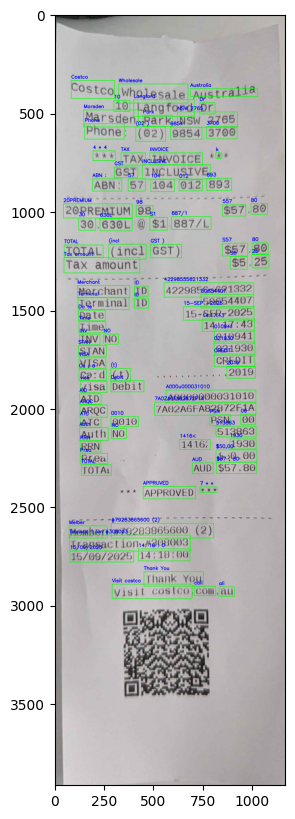

In [16]:
import cv2
import matplotlib.pyplot as plt
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
for (bbox, text, prob) in results:
    (top_left, top_right, bottom_right, bottom_left) = bbox
    top_left = (int(top_left[0]), int(top_left[1]))
    bottom_right = (int(bottom_right[0]), int(bottom_right[1]))
    image = cv2.rectangle(image, top_left, bottom_right, (0, 255, 0), 2)
    image = cv2.putText(image, text, (top_left[0], top_left[1] - 10), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)
    
plt.figure(figsize=(10,10))
plt.imshow(image)

In [ ]:
#extracted_text = "\n".join([res[1] for res in results]) # Extract only the text
reader.
print(extracted_text)

Wholesale
10
Langford
Dr
Marsden
Park
NSW 2765
Phone
(02 )
9854
3700
4 * 4
k
TAX
INVOICE
GST
INCLUSIVE
ABN :
57
104
012
893
20PREMIUM
98
557
80
30
630L
S1
887/1
TOTAL
(incl
GST )
S57
80
Tax amount
S5
25
Merchant
ID
42298555621332
Terminal
I0
50654407
Da te
15-SEP -2025
Time
14:17:43
INV
NO
010941
STAN
021930
VISA
CREDIT
Ca ; d
(t)
2019
visa
Debit
AID
A000u000031010
ARQC
7AOZAGFA82872F1A
ATC
0010
PSN
00
Auth
NO
513863
RRN
1416<
1930
Prea
$50,00
TOTAL
AUD
$57 , 80
7 * *
APPRUVED
Melber
#79283865600 (2)
Transac t ion #308003
15/09/2025
14: 18 : 0
Thank You
Visit costco
coii
ali
Costco
Australia


## Pytesseract OCR

In [3]:
import cv2
from PIL import Image
import pytesseract

# Replace with your actual Tesseract installation path
pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'

## Pre-processing

In [ ]:

import numpy as np
import tempfile

img = Image.open(image_path)

# Image Scaling
def imageScale(image):
    temp_file = tempfile.NamedTemporaryFile(delete=False, suffix='.jpg')
    temp_filename = temp_file.name
    scaled_img = image.save(temp_filename, dpi=(300, 300))
    return scaled_img
scaled_img = imageScale(img)

# Load image using OpenCV
img = cv2.imread(image_path)
norm_img = np.zeros((img.shape[0], img.shape[1]))


# Normalization
def normalize(image):
    norm_img = cv2.normalize(img, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX)
    return norm_img
normalized_img = normalize(norm_img)

# Skew Correction
def deskew(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # Apply thresholding
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    # Find contours
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Calculate skew angle
    angle = 0
    if contours:
        # Find the largest contour (assuming it represents the main text block)
        largest_contour = max(contours, key=cv2.contourArea)
        rect = cv2.minAreaRect(largest_contour)
        angle = rect[2] # The angle of the rotated rectangle

        # Adjust angle if it's in the range (-90, -45] for text orientation
        if angle < -45:
            angle = 90 + angle
    
    # Rotate the image to deskew
    (h, w) = img.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    deskewed_img = cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)
    
    return deskewed_img
#deskewed_img = deskew(normalized_img)

# Contrast Adjustment
alpha = 1.4  # Contrast control (1.0-3.0)
beta = 0.5     # Brightness control (0-100)
def adjustConstrast(image, alpha, beta):
    contrasted = cv2.convertScaleAbs(image, alpha=alpha, beta=beta)
    return contrasted
#contrasted_img = adjustConstrast(normalized_img, alpha, beta)

# Convert to grayscale
def toGrayscale(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return gray
gray_img = toGrayscale(normalized_img)

# Denoise image
# denoised = cv2.medianBlur(contrasted, 5) # 5 is the kernel size

# # Thresholding/Binarize image
# _, binarized = cv2.threshold(denoised, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Dilation and Erosion
# kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3,3))
# dilated = cv2.dilate(denoised, kernel, iterations=1)

# Pass the processed image (as a PIL Image object) to pytesseract
results = pytesseract.image_to_string(Image.fromarray(gray_img))
print(results)

COStco Wholesale australia
10 Langford Dr
| Marsden Park NSW 2765
: Phone: (02) 9854 3700

+e TARR LNVOSGE ~~.
GST INCLUSIVE
ABN: 57 104 012 893

2OPREMIUM 98 $57 . 80
30,630L @ $1.887/L

TOTAL (incl GST) $57 .80

Tax amount $5.25
Merchant ID 422985556271332

Terminal 1D 50654407
Date 15-SEP-2025

Time 14:17:43
INV NO 10941
STAN 021930
VISA CREDIT
Ge7d (2) © a eee 2019
Visa Debit
AID AQVOGU000031010
ARQC TAOZAGFAB2872F 1A
ATC 010 PSN 00
Auth NO 513863
RRN 14167" 1930
Prea . $50.00
TOTAL AUD $57,80

*** APPROVED ***

Member #79283865600 (2)
Transaction #308006
15/09/2025 14:18:00

Thank You
Visit costco,com,au




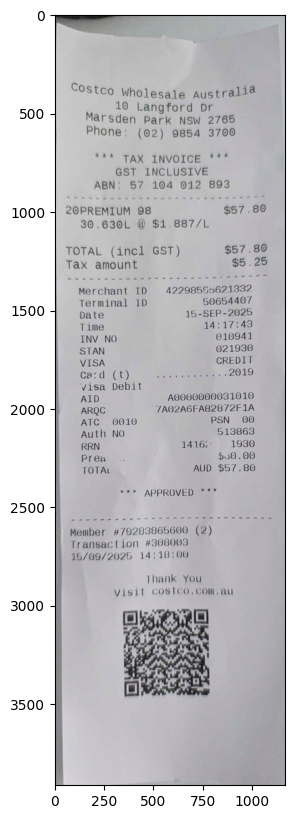

In [14]:
import matplotlib.pyplot as plt
orig_img = cv2.imread(image_path)
plt.figure(figsize=(10,10))
plt.imshow(orig_img)

In [ ]:
# Save the Text Results to a DataFrame for further processing
import pandas as pd

data = pd.DataFrame(results.split('\n'))
print(data)

                              0
0    Costco Wholesale australia
1                10 Langford Dr
2         Marsden Park NSW 2765
3         Phone: (02) 9854 3700
4                              
5           “** TAX INVOICE ***
6                 GST INCLUSIVE
7           ABN: 57 104 012 893
8                              
9         2OPREMIUM 98 $57 . 80
10           30.630L @ $1 887/L
11     TOTAL (incl GST) $57 .80
12                             
13             Tax amount $5 25
14                             
15   Merchant ID 42298555621332
16                             
17         Terminal 1D 50654407
18             Date 15-SEP-2025
19                Time 14:17:43
20                 INV NO 10941
21                  STAN 021930
22                  VISA CREDIT
23  Card (ty vue vveeenees 2019
24                   visa Debit
25                             
26          AID AVOOVOHOO3 1010
27       ARQC TAOZAGFAB2872F 1A
28               ATC 010 PSN OO
29               Auth NO 513863
30      

In [ ]:
## Sample Output Format
## Petrol variant: price
## Total Volume: price per litre
## Total Cost: total cost
## Date-Time: date-time

for i in data:
    if 